In [1]:
import networkx as nx
from algorithms.cascade import simulate_cascade

# Piccolo grafo di test: un triangolo attaccato a un nodo esterno
G_test = nx.Graph()
G_test.add_edges_from([(1, 2), (2, 3), (1, 3), (3, 4)])
# nodo 4 ha come unico vicino il nodo 3 (grado 1, soglia 0.5)
# se attivo S={1,2}: nodo 3 ha 2 vicini attivi su 3 (grado 3, soglia 1.5) -> si attiva
# poi nodo 4 ha 1 vicino attivo su 1 (grado 1, soglia 0.5) -> si attiva

result = simulate_cascade(G_test, {1, 2})
print(result)  # atteso: {1, 2, 3, 4}

{1, 2, 3, 4}


In [11]:
import networkx as nx

G = nx.read_edgelist("data/CA-AstroPh.txt", comments="#", nodetype=int)

# --- Controllo e rimozione dei self-loop ---
n_self_loops = nx.number_of_selfloops(G)
print(f"Self-loop trovati: {n_self_loops}")

if n_self_loops > 0:
    G.remove_edges_from(nx.selfloop_edges(G))
    print(f"Self-loop rimossi. Nuovo numero di archi: {G.number_of_edges()}")

# G ripulito.
# --- Componente connessa più grande ---

largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

Self-loop trovati: 60
Self-loop rimossi. Nuovo numero di archi: 198050


Costo minimo:  1
Costo massimo: 252
Costo medio:   11.26
Costo mediano: 5.0
Costo totale:  201526
25° percentile: 2.0
75° percentile: 14.0
90° percentile: 28.0


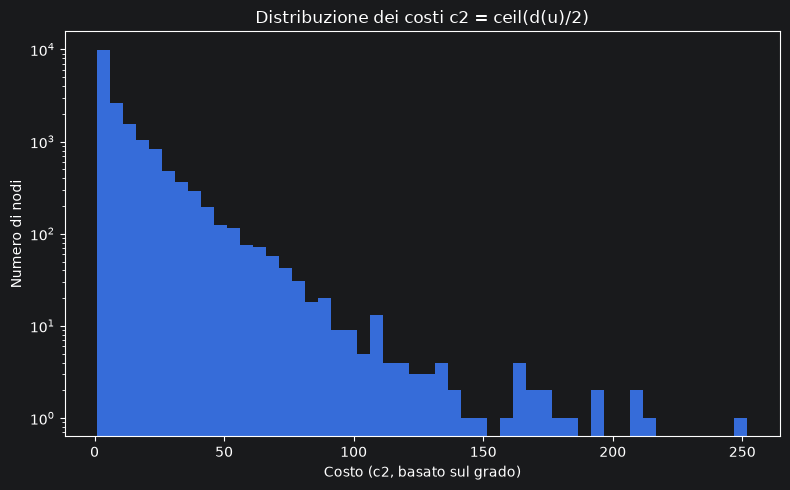

In [12]:
from algorithms.cost_functions import cost_degree
import numpy as np
import matplotlib.pyplot as plt

# Calcola i costi con la funzione basata sul grado
c2_costs = cost_degree(G_lcc)
values = np.array(list(c2_costs.values()))

print(f"Costo minimo:  {values.min()}")
print(f"Costo massimo: {values.max()}")
print(f"Costo medio:   {values.mean():.2f}")
print(f"Costo mediano: {np.median(values):.1f}")
print(f"Costo totale:  {values.sum()}")
print(f"25° percentile: {np.percentile(values, 25):.1f}")
print(f"75° percentile: {np.percentile(values, 75):.1f}")
print(f"90° percentile: {np.percentile(values, 90):.1f}")

# Istogramma per farsi un'idea visiva della distribuzione
plt.figure(figsize=(8, 5))
plt.hist(values, bins=50)
plt.xlabel("Costo (c2, basato sul grado)")
plt.ylabel("Numero di nodi")
plt.title("Distribuzione dei costi c2 = ceil(d(u)/2)")
plt.yscale("log")  # utile perché la distribuzione è probabilmente molto sbilanciata
plt.tight_layout()
plt.show()

In [5]:
import time
from algorithms.variant.cs_greedy_new import cost_seeds_greedy
from algorithms.cascade import simulate_cascade
from algorithms.cost_functions import cost_degree

c2 = cost_degree(G_lcc)
k_test = 100  # budget piccolo, giusto per un primo test di velocità

start = time.time()
S = cost_seeds_greedy(G_lcc, k_test, c2, "f1")
print(f"Tempo: {time.time() - start:.2f}s, |S| = {len(S)}, costo = {sum(c2[u] for u in S)}")

inf = simulate_cascade(G_lcc, S)
print(f"|Inf[G,S]| = {len(inf)}")

Tempo: 0.78s, |S| = 9, costo = 98
|Inf[G,S]| = 13


In [13]:
from algorithms.wtss import wtss
from algorithms.cascade import simulate_cascade
from algorithms.cost_functions import cost_degree
import time

c2 = cost_degree(G_lcc)
k_test = 100

start = time.time()
S = wtss(G_lcc, k_test, c2)
print(f"Tempo: {time.time() - start:.2f}s, |S| = {len(S)}, costo = {sum(c2[u] for u in S)}")

inf = simulate_cascade(G_lcc, S)
print(f"|Inf[G,S]| = {len(inf)}")

Tempo: 0.02s, |S| = 69, costo = 100
|Inf[G,S]| = 121


In [23]:
from algorithms.my_seeds import my_seeds
from algorithms.cascade import simulate_cascade
from algorithms.cost_functions import cost_degree
import time

c2 = cost_degree(G_lcc)
k_test = 100

start = time.time()
S = my_seeds(G_lcc, k_test, c2)
print(f"Tempo: {time.time() - start:.2f}s, |S| = {len(S)}, costo = {sum(c2[u] for u in S)}")

inf = simulate_cascade(G_lcc, S)
print(f"|Inf[G,S]| = {len(inf)}")

Tempo: 0.13s, |S| = 23, costo = 100
|Inf[G,S]| = 27
